In [ ]:
import os

# Core LSD imports
from sclsd.train import LSD
from sclsd.plotting import plot_random_walks

from sclsd.core import LSDConfig
from sclsd.utils import set_all_seeds
from sclsd.utils.seed import clear_pyro_state

# Deep learning
import torch

# Single-cell analysis
import scanpy as sc


print(f"PyTorch version: {torch.__version__}")
print(f"Scanpy version: {sc.__version__}")

/scratch/apour/conda/envs/sclsd/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch version: 2.4.1+cu121
Scanpy version: 1.11.5


/projects/apour/.cache/tmp/ipykernel_2899536/3031178149.py:20: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print(f"Scanpy version: {sc.__version__}")


In [ ]:
# Configure computational device
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
SEED = 42
set_all_seeds(SEED)

Using device: cuda:1
GPU Name: NVIDIA GeForce RTX 3090
GPU Memory: 25.44 GB


## Section 2: Data Loading and Exploration

Load the preprocessed dentate gyrus dataset and explore its structure.

In [3]:
# Load preprocessed dentate gyrus data
# This dataset contains adult hippocampal neurogenesis cells
# Already normalized with:
# - Log-normalized gene expression in .X
# - Raw counts in .layers['raw']
# - Library sizes in .obs['librarysize']

data_path = "../../Zenodo/DentateGyrus/preprocessed_adata.h5ad"
adata = sc.read(data_path)

In [4]:
# Define the differentiation phylogeny for dentate gyrus neurogenesis
# This represents the known biological progression:
# - Neuronal lineage: nIPC → Neuroblast → Granule immature → Granule mature
# - Glial lineage: nIPC → Radial Glia-like → Astrocytes

phylogeny = {
    "nIPC":             ["Neuroblast", "Radial Glia-like"],  # Progenitor bifurcation
    "Neuroblast":       ["Granule immature"],                # Neuronal commitment
    "Granule immature": ["Granule mature"],                  # Neuronal maturation
    "Granule mature":   [],                                  # Terminal neuronal state
    "Radial Glia-like": ["Astrocytes"],                     # Glial differentiation
    "Astrocytes":       []                                   # Terminal glial state
}

print("Differentiation phylogeny defined:")
print("\nNeuronal lineage:")
print("  nIPC → Neuroblast → Granule immature → Granule mature")
print("\nGlial lineage:")
print("  nIPC → Radial Glia-like → Astrocytes")
print("\nBifurcation point: nIPC (neural intermediate progenitor cells)")

Differentiation phylogeny defined:

Neuronal lineage:
  nIPC → Neuroblast → Granule immature → Granule mature

Glial lineage:
  nIPC → Radial Glia-like → Astrocytes

Bifurcation point: nIPC (neural intermediate progenitor cells)


Initializing LSD model for dentate gyrus neurogenesis...
[LSD] Removing 3 cells with no transitions:
[LSD] Prior transition matrix set from phylogeny and pseudotime.


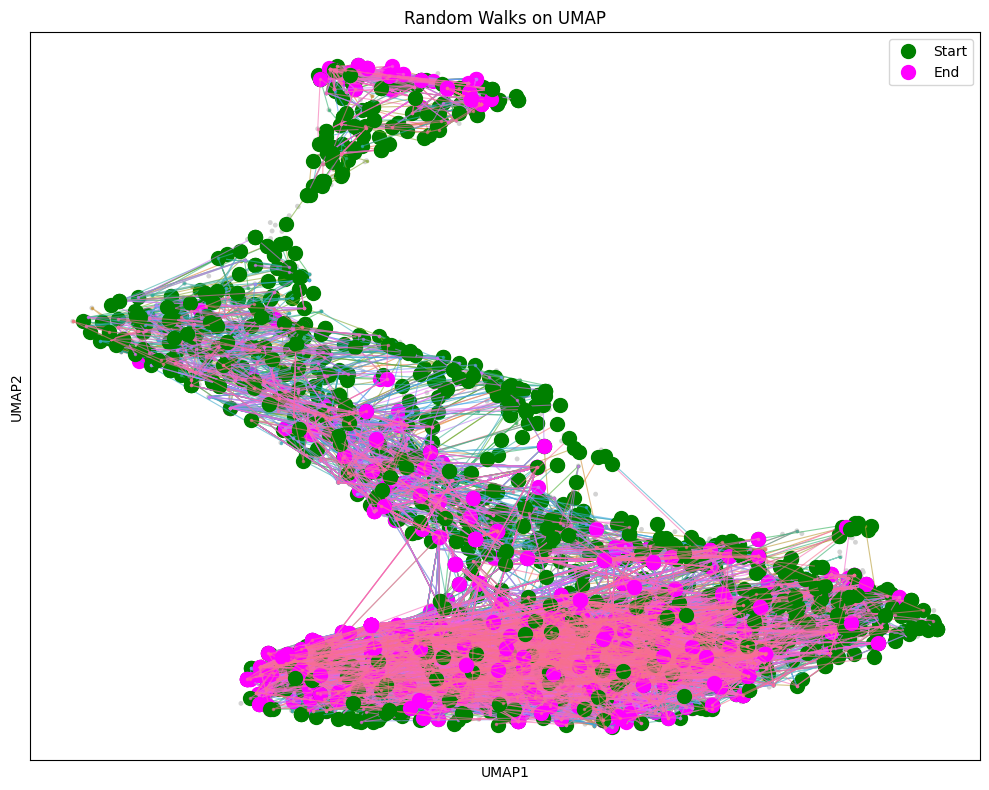

In [5]:
# Initialize the LSD model
print("Initializing LSD model for dentate gyrus neurogenesis...")
cfg = LSDConfig()
cfg.optimizer.adam.lr = 2e-3
cfg.walks.path_len = 12
cfg.walks.num_walks = 2048

lsd = LSD(
    adata,                           # Single-cell data
    cfg,
    device=device,                   # Computation device
    lib_size_key="librarysize",      # Column name for library sizes
    raw_count_key="raw",             # Layer name for raw counts
)
# Set phylogeny constraints and prior transitions
lsd.set_phylogeny(phylogeny, cluster_key="clusters")
#set prior pseudotime key
lsd.set_prior_transition(prior_time_key="prior_pseudotime")
#prepare random walks
lsd.prepare_walks()
#plot random walks
plot_random_walks(lsd.adata, lsd.walks, "X_umap")


Model checkpoints will be saved to: ./model


Training Epochs: 100%|██████████| 250/250 [13:15<00:00,  3.18s/it, -ELBO=0.4993, Potential Metric=0.0559, Entropy Metric=0.0508]


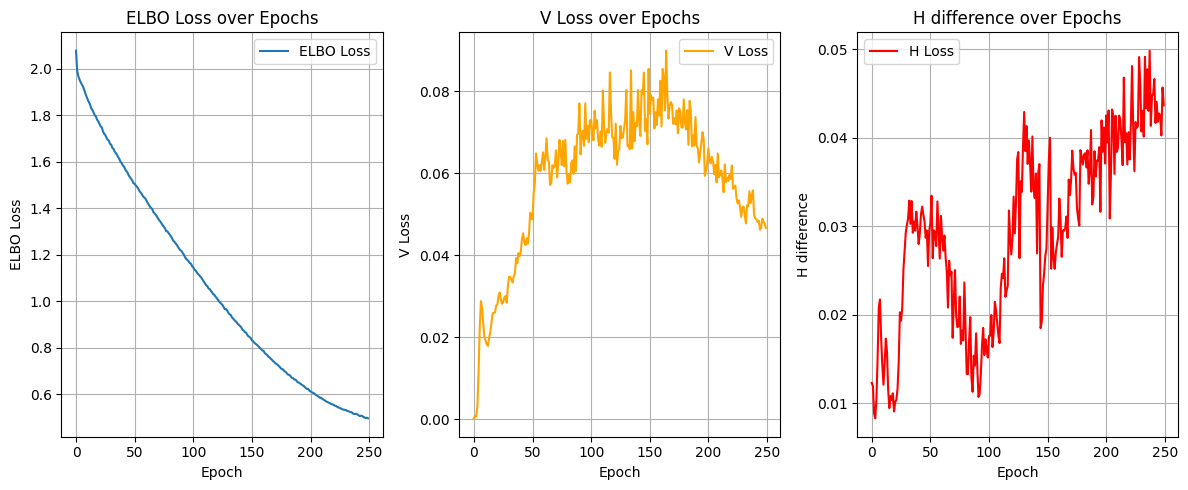

In [6]:
# Clear any existing parameters
clear_pyro_state()
num_epochs = 250
# Create save directory for model checkpoints
save_dir = "./model"
os.makedirs(save_dir, exist_ok=True)
print(f"Model checkpoints will be saved to: {save_dir}")

# Train the model
lsd.train(
    num_epochs=num_epochs,      # 250 epochs
    save_dir=save_dir,          # Directory for checkpoints
    save_interval=50,           # Save every 50 epochs
)